In [2]:
!pip install numpy pandas matplotlib seaborn scikit-learn

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
df= pd.read_csv('healthcare.csv')
df.head()

,Patient Id,Patient Admission Date,Patient Admission Time,Merged,Patient Gender,Patient Age,Patient Race,Department Referral,Patient Admission Flag,Patient Satisfaction Score,Patient Waittime
0,780-96-6113,9/9/2024,9:25:00 AM,W. Breede,Female,63,African American,NaN,Not Admission,5.0,32
1,714-35-6722,9/9/2024,4:42:00 PM,Y. Baldetti,Male,31,Asian,Orthopedics,Not Admission,NaN,22
2,571-85-3714,9/9/2024,12:14:00 AM,M. Semerad,Male,75,White,General Practice,Not Admission,NaN,16
3,404-43-9499,9/9/2024,8:33:00 PM,K. Blaydes,Male,79,African American,General Practice,Admission,NaN,38
4,552-51-5855,9/9/2024,7:25:00 PM,F. Dickerson,Female,24,African American,NaN,Admission,NaN,36


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9216 entries, 0 to 9215
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Patient Id                  9216 non-null   object 
 1   Patient Admission Date      9216 non-null   object 
 2   Patient Admission Time      9216 non-null   object 
 3   Merged                      9216 non-null   object 
 4   Patient Gender              9216 non-null   object 
 5   Patient Age                 9216 non-null   int64  
 6   Patient Race                9216 non-null   object 
 7   Department Referral         3816 non-null   object 
 8   Patient Admission Flag      9216 non-null   object 
 9   Patient Satisfaction Score  2517 non-null   float64
 10  Patient Waittime            9216 non-null   int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 792.1+ KB


In [6]:
df.describe()

,Patient Age,Patient Satisfaction Score,Patient Waittime
count,9216.000000,2517.000000,9216.000000
mean,39.855143,4.992054,35.259874
std,22.755125,3.138043,14.735323
min,1.000000,0.000000,10.000000
25%,20.000000,2.000000,23.000000
50%,39.000000,5.000000,35.000000
75%,60.000000,8.000000,48.000000
max,79.000000,10.000000,60.000000


In [7]:
df.isna().sum()

Patient Id                       0
Patient Admission Date           0
Patient Admission Time           0
Merged                           0
Patient Gender                   0
Patient Age                      0
Patient Race                     0
Department Referral           5400
Patient Admission Flag           0
Patient Satisfaction Score    6699
Patient Waittime                 0
dtype: int64

In [8]:
df['Patient Race'].unique()

array(['African American', 'Asian', 'White', 'Two or More Races',
       'Declined to Identify', 'Native American/Alaska Native',
       'Pacific Islander'], dtype=object)

In [9]:
df.shape

(9216, 11)

In [10]:
df['Department Referral'].head()

0                 NaN
1         Orthopedics
2    General Practice
3    General Practice
4                 NaN
Name: Department Referral, dtype: object

In [11]:
df['Department Referral'].fillna('Not Listed',inplace=True)

In [12]:
df['Department Referral'].head()

0          Not Listed
1         Orthopedics
2    General Practice
3    General Practice
4          Not Listed
Name: Department Referral, dtype: object

<Axes: xlabel='Patient Satisfaction Score', ylabel='Count'>

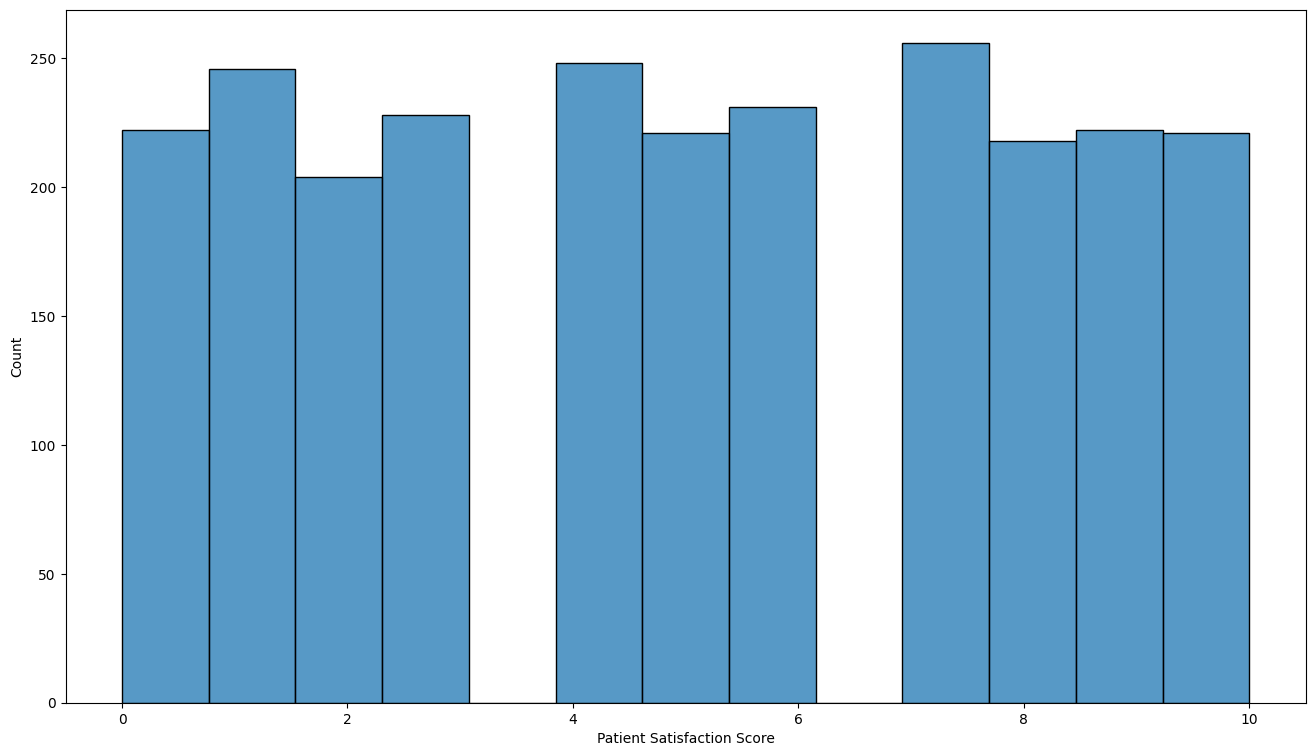

In [13]:
plt.figure(figsize=(16, 9))
sns.histplot(data = df , x = 'Patient Satisfaction Score')

In [14]:
df['Patient Satisfaction Score'].unique()

array([ 5., nan,  6.,  7.,  2.,  3.,  0.,  1.,  4., 10.,  8.,  9.])

In [15]:
df['Patient Satisfaction Score']=df['Patient Satisfaction Score'].fillna(df['Patient Satisfaction Score'].median())

<Axes: xlabel='Patient Satisfaction Score', ylabel='Count'>

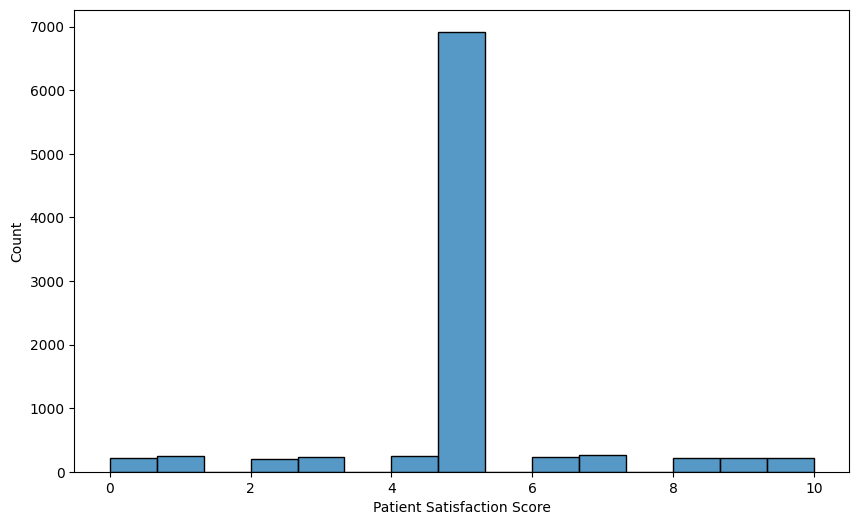

In [16]:
plt.figure(figsize=(10, 6))
sns.histplot(data = df , x = 'Patient Satisfaction Score')

In [17]:
df['Patient Satisfaction Score'].value_counts()

Patient Satisfaction Score
5.0     6920
7.0      256
4.0      248
1.0      246
6.0      231
3.0      228
0.0      222
9.0      222
10.0     221
8.0      218
2.0      204
Name: count, dtype: int64

In [18]:
df.head()

,Patient Id,Patient Admission Date,Patient Admission Time,Merged,Patient Gender,Patient Age,Patient Race,Department Referral,Patient Admission Flag,Patient Satisfaction Score,Patient Waittime
0,780-96-6113,9/9/2024,9:25:00 AM,W. Breede,Female,63,African American,Not Listed,Not Admission,5.0,32
1,714-35-6722,9/9/2024,4:42:00 PM,Y. Baldetti,Male,31,Asian,Orthopedics,Not Admission,5.0,22
2,571-85-3714,9/9/2024,12:14:00 AM,M. Semerad,Male,75,White,General Practice,Not Admission,5.0,16
3,404-43-9499,9/9/2024,8:33:00 PM,K. Blaydes,Male,79,African American,General Practice,Admission,5.0,38
4,552-51-5855,9/9/2024,7:25:00 PM,F. Dickerson,Female,24,African American,Not Listed,Admission,5.0,36


In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
age_bins = [0,18,35,60,100]
age_labels = ['Pediatric','Young Adult','Adult','Senior']

In [21]:
df['Age Group'] = pd.cut(df['Patient Age'],bins = age_bins, labels=age_labels)

In [22]:
df[['Patient Age','Age Group']].head()

,Patient Age,Age Group
0,63,Senior
1,31,Young Adult
2,75,Senior
3,79,Senior
4,24,Young Adult


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9216 entries, 0 to 9215
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   Patient Id                  9216 non-null   object  
 1   Patient Admission Date      9216 non-null   object  
 2   Patient Admission Time      9216 non-null   object  
 3   Merged                      9216 non-null   object  
 4   Patient Gender              9216 non-null   object  
 5   Patient Age                 9216 non-null   int64   
 6   Patient Race                9216 non-null   object  
 7   Department Referral         9216 non-null   object  
 8   Patient Admission Flag      9216 non-null   object  
 9   Patient Satisfaction Score  9216 non-null   float64 
 10  Patient Waittime            9216 non-null   int64   
 11  Age Group                   9216 non-null   category
dtypes: category(1), float64(1), int64(2), object(8)
memory usage: 801.3+ KB


In [24]:
df.head(10)

,Patient Id,Patient Admission Date,Patient Admission Time,Merged,Patient Gender,Patient Age,Patient Race,Department Referral,Patient Admission Flag,Patient Satisfaction Score,Patient Waittime,Age Group
0,780-96-6113,9/9/2024,9:25:00 AM,W. Breede,Female,63,African American,Not Listed,Not Admission,5.0,32,Senior
1,714-35-6722,9/9/2024,4:42:00 PM,Y. Baldetti,Male,31,Asian,Orthopedics,Not Admission,5.0,22,Young Adult
2,571-85-3714,9/9/2024,12:14:00 AM,M. Semerad,Male,75,White,General Practice,Not Admission,5.0,16,Senior
3,404-43-9499,9/9/2024,8:33:00 PM,K. Blaydes,Male,79,African American,General Practice,Admission,5.0,38,Senior
4,552-51-5855,9/9/2024,7:25:00 PM,F. Dickerson,Female,24,African American,Not Listed,Admission,5.0,36,Young Adult
5,736-98-3342,9/9/2024,12:05:00 PM,B. Glasman,Male,27,Asian,Not Listed,Not Admission,5.0,52,Young Adult
6,634-04-5264,9/9/2024,5:25:00 PM,R. Possek,Female,70,White,General Practice,Not Admission,5.0,57,Senior
7,237-07-3349,9/9/2024,7:46:00 PM,H. Cloake,Female,64,Two or More Races,General Practice,Not Admission,5.0,13,Senior
8,695-54-0916,9/9/2024,12:34:00 PM,G. Tregonna,Female,69,Two or More Races,General Practice,Not Admission,5.0,48,Senior
9,536-68-0475,9/9/2024,1:14:00 PM,T. Shillaker,Female,25,African American,General Practice,Admission,6.0,14,Young Adult


In [25]:
df['Admission Timestamp'] = pd.to_datetime(df['Patient Admission Date'] + ' ' + df['Patient Admission Time'],
                                           dayfirst=True)

In [26]:
df['Hour'] = df['Admission Timestamp'].dt.hour

In [27]:
df['Day'] = df['Admission Timestamp'].dt.day_name()

In [28]:
df[['Admission Timestamp', 'Hour', 'Day']].head()

,Admission Timestamp,Hour,Day
0,2024-09-09 09:25:00,9,Monday
1,2024-09-09 16:42:00,16,Monday
2,2024-09-09 00:14:00,0,Monday
3,2024-09-09 20:33:00,20,Monday
4,2024-09-09 19:25:00,19,Monday


In [29]:
df['Patient Gender'].unique()

array(['Female', 'Male', 'Femaleemale'], dtype=object)

In [30]:
df['Patient Gender'] = df['Patient Gender'].replace('Femaleemale', 'Female')

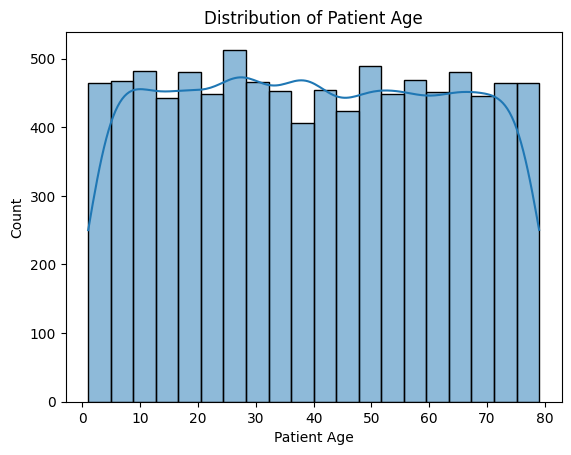

In [31]:
plt.Figure(figsize=(10,6))
sns.histplot(data = df, x = 'Patient Age',bins = 20 ,kde=True)
plt.title('Distribution of Patient Age')
plt.show()

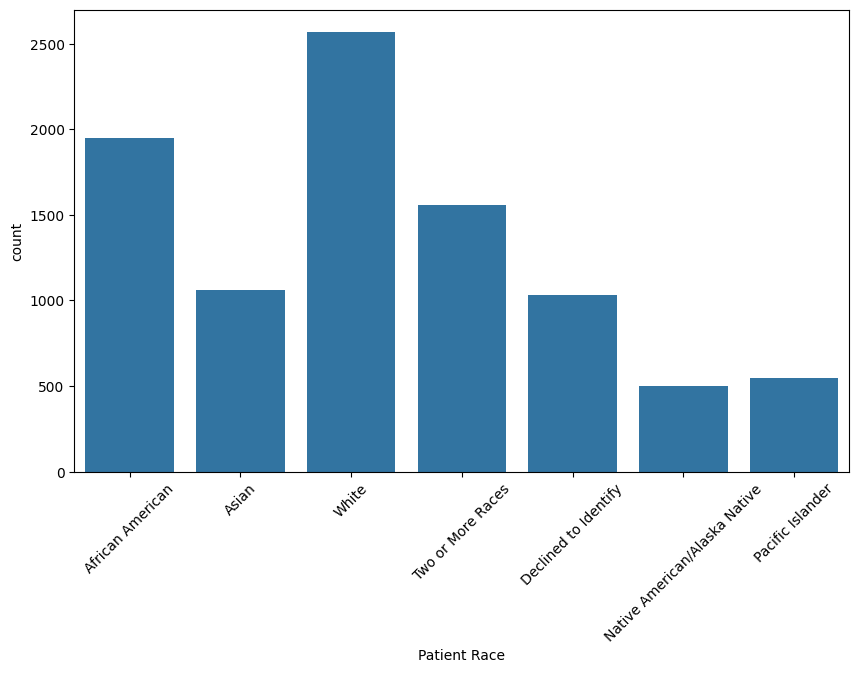

In [32]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Patient Race')
plt.xticks(rotation=45) 
plt.show()

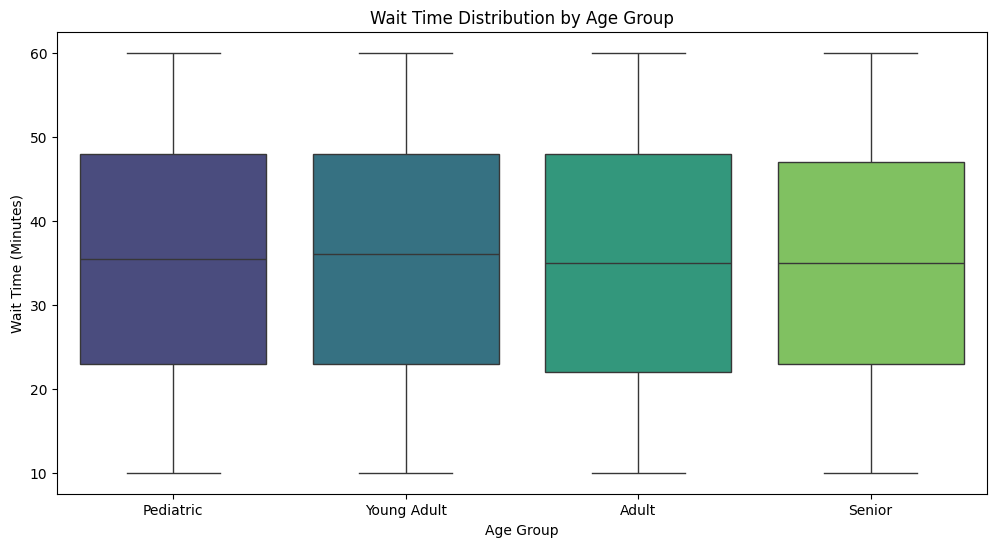

In [33]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Age Group', y='Patient Waittime', palette='viridis')
plt.title('Wait Time Distribution by Age Group')
plt.ylabel('Wait Time (Minutes)')
plt.show()

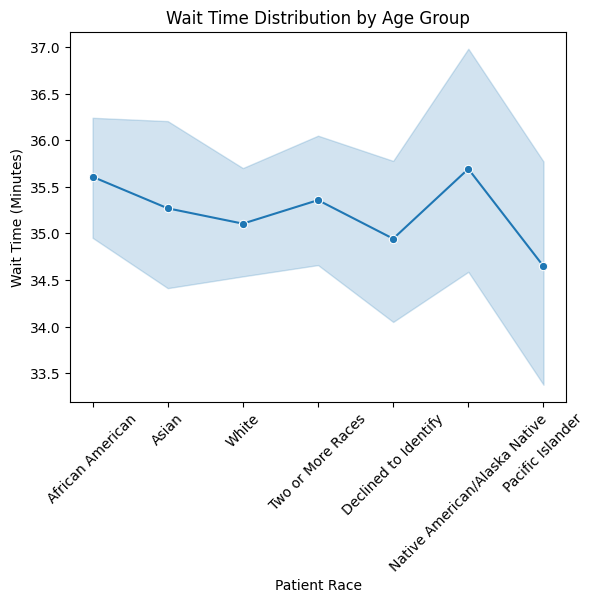

In [34]:
plt.Figure(figsize=(12,6))
sns.lineplot(data=df,x='Patient Race', y='Patient Waittime',palette='viridis',marker='o')
plt.title('Wait Time Distribution by Age Group')
plt.xticks(rotation=45)
plt.ylabel('Wait Time (Minutes)')
plt.show()


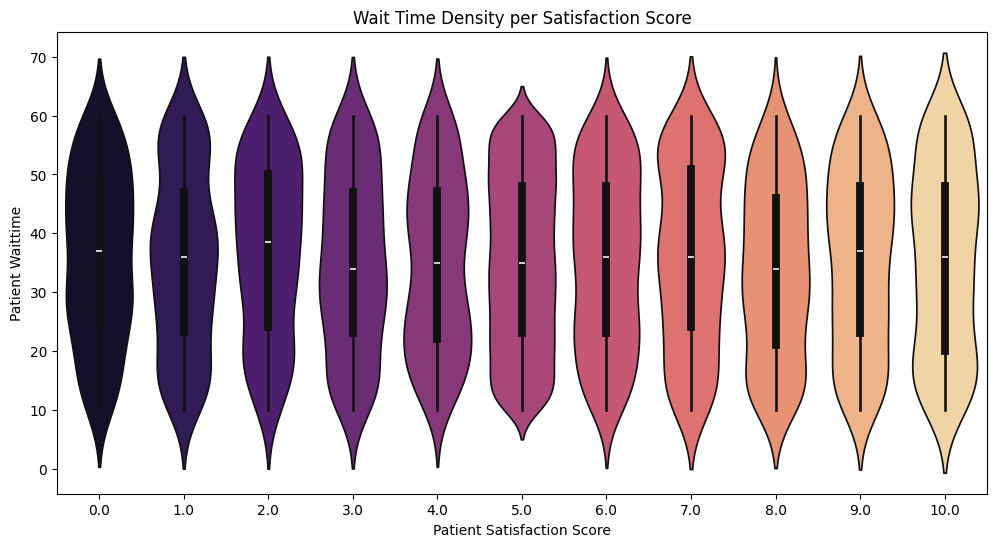

In [35]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x='Patient Satisfaction Score', y='Patient Waittime', palette='magma')
plt.title('Wait Time Density per Satisfaction Score')
plt.show()

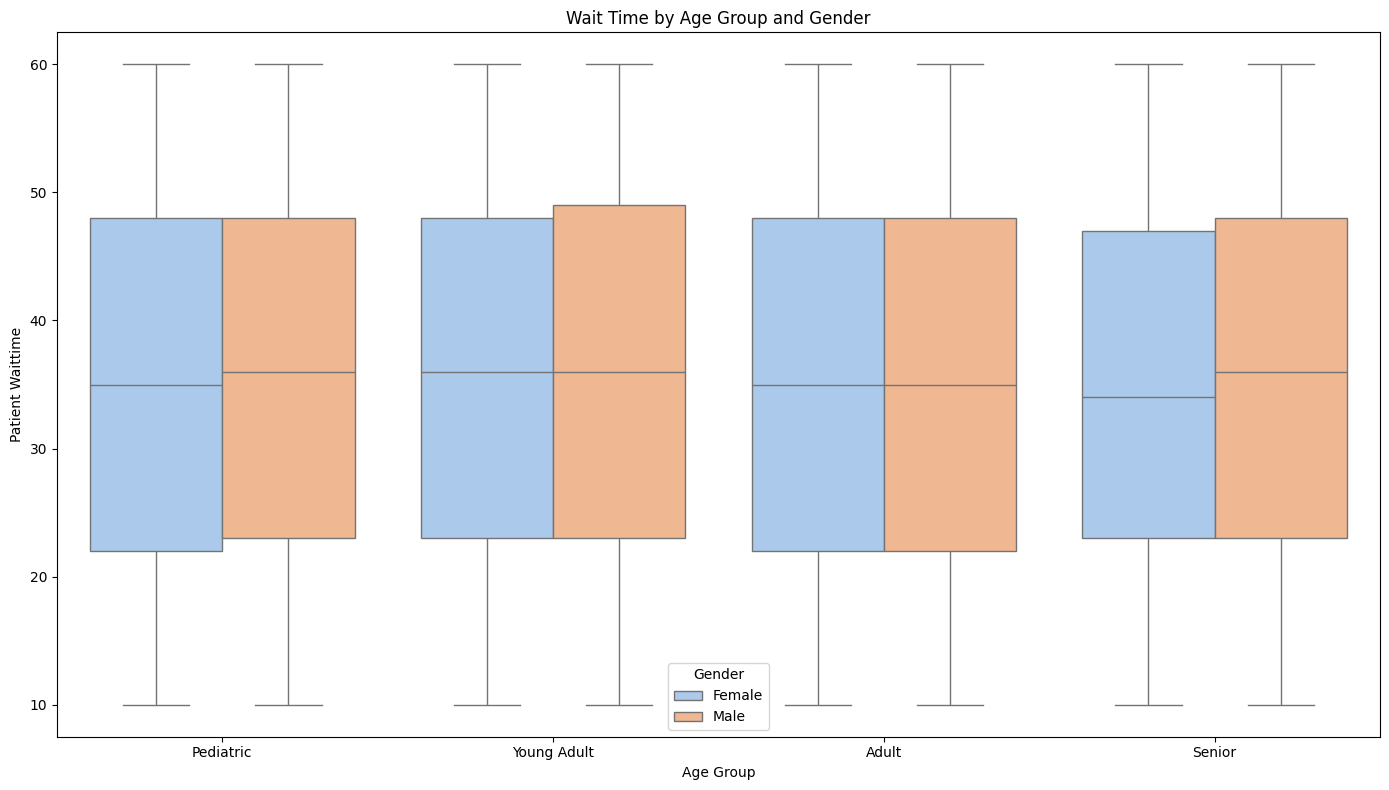

In [36]:
plt.figure(figsize=(14, 8))
sns.boxplot(data=df, x='Age Group', y='Patient Waittime', hue='Patient Gender', palette='pastel')
plt.title('Wait Time by Age Group and Gender')
plt.legend(title='Gender', loc='best')
plt.tight_layout()
plt.show()

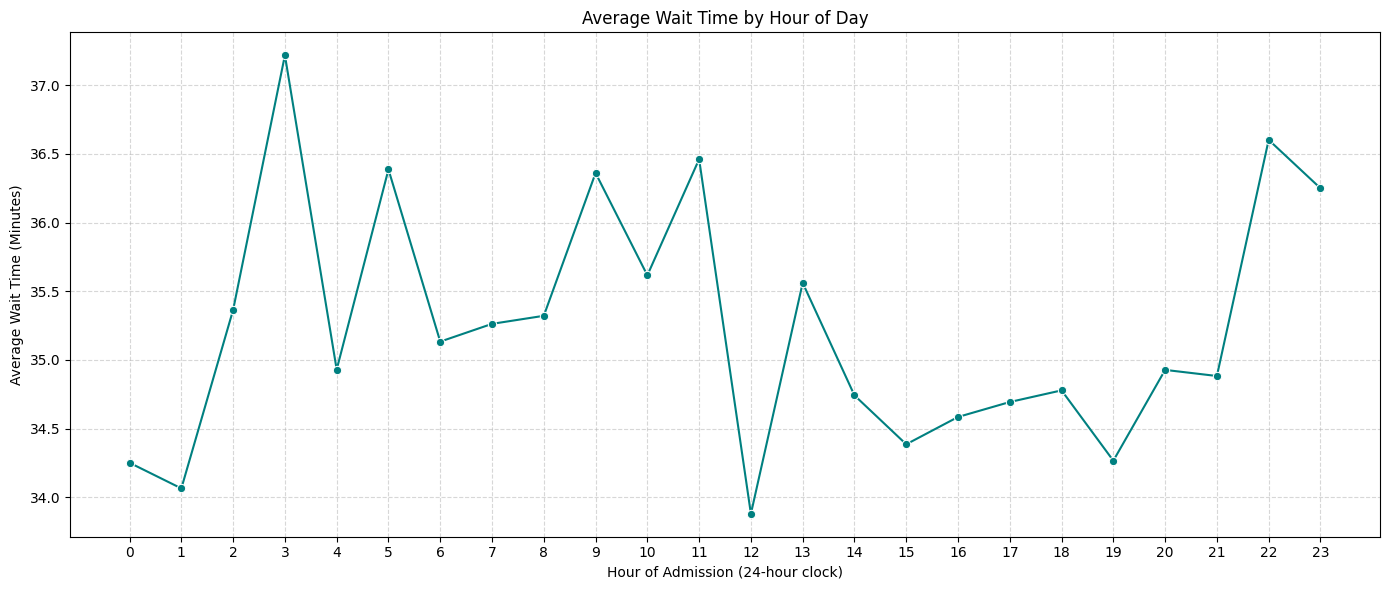

In [37]:
plt.figure(figsize=(14, 6))

sns.lineplot(data=df, x='Hour', y='Patient Waittime', color='teal', marker='o', errorbar=None)

plt.title('Average Wait Time by Hour of Day')
plt.xlabel('Hour of Admission (24-hour clock)')
plt.ylabel('Average Wait Time (Minutes)')
plt.xticks(range(0, 24)) 
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [39]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse_output=False, drop='first')
categorical_cols = ['Patient Gender', 'Department Referral', 'Day']
encoded_data = ohe.fit_transform(df[categorical_cols])
encoded_df = pd.DataFrame(encoded_data,columns=ohe.get_feature_names_out(categorical_cols))

In [41]:
encoded_df.head(10)

,Patient Gender_Male,Department Referral_Gastroenterology,Department Referral_General Practice,Department Referral_Neurology,Department Referral_Not Listed,Department Referral_Orthopedics,Department Referral_Physiotherapy,Department Referral_Renal,Day_Monday,Day_Saturday,Day_Sunday,Day_Thursday,Day_Tuesday,Day_Wednesday
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
5,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
9,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [50]:
from sklearn.preprocessing import OrdinalEncoder

age_order = [['Pediatric', 'Young Adult', 'Adult', 'Senior']]
oe = OrdinalEncoder(categories=age_order)

df['Age Group'] = oe.fit_transform(df[['Age Group']])

ValueError: could not convert string to float: 'Pediatric'

In [53]:
df['Age Group'].head(20)

0     3.0
1     1.0
2     3.0
3     3.0
4     1.0
5     1.0
6     3.0
7     3.0
8     3.0
9     1.0
10    2.0
11    0.0
12    2.0
13    2.0
14    1.0
15    2.0
16    0.0
17    1.0
18    2.0
19    0.0
Name: Age Group, dtype: float64

In [55]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[['Patient Age', 'Hour']] = scaler.fit_transform(df[['Patient Age', 'Hour']])

In [56]:
df['Patient Age']

0       1.017182
1      -0.389171
2       1.544565
3       1.720359
4      -0.696810
          ...   
9211   -0.916553
9212   -0.784707
9213   -1.399987
9214   -0.125479
9215    0.841388
Name: Patient Age, Length: 9216, dtype: float64

In [57]:
df.to_csv('Hospital_Data_Cleaned_Swapnil.csv', index=False)

print("Project ready for GitHub upload!")

Project ready for GitHub upload!


In [58]:
df.head()

,Patient Id,Patient Admission Date,Patient Admission Time,Merged,Patient Gender,Patient Age,Patient Race,Department Referral,Patient Admission Flag,Patient Satisfaction Score,Patient Waittime,Age Group,Admission Timestamp,Hour,Day
0,780-96-6113,9/9/2024,9:25:00 AM,W. Breede,Female,1.017182,African American,Not Listed,Not Admission,5.0,32,3.0,2024-09-09 09:25:00,-0.357502,Monday
1,714-35-6722,9/9/2024,4:42:00 PM,Y. Baldetti,Male,-0.389171,Asian,Orthopedics,Not Admission,5.0,22,1.0,2024-09-09 16:42:00,0.649007,Monday
2,571-85-3714,9/9/2024,12:14:00 AM,M. Semerad,Male,1.544565,White,General Practice,Not Admission,5.0,16,3.0,2024-09-09 00:14:00,-1.651584,Monday
3,404-43-9499,9/9/2024,8:33:00 PM,K. Blaydes,Male,1.720359,African American,General Practice,Admission,5.0,38,3.0,2024-09-09 20:33:00,1.224155,Monday
4,552-51-5855,9/9/2024,7:25:00 PM,F. Dickerson,Female,-0.696810,African American,Not Listed,Admission,5.0,36,1.0,2024-09-09 19:25:00,1.080368,Monday
